# 1 Importar librerías

In [1]:
# Revisar coincidencias difusas entre cadenas de texto
#!pip install geopandas plotly shapely folium fuzzywuzzy python-Levenshtein
#!pip install pandas gradio matplotlib openai tqdm

# Util cuando ciertas advertencias no son críticas y o queremos que aparezcan en la salida
import warnings
warnings.filterwarnings('ignore')

# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px

# Datos geoespaciales
#import geopandas as gpd
#from shapely.geometry import shape
#import folium

# Utilidades y manejo de archivos
import glob
import os

# Autorización para que GoogleColab acceda a Drive
from google.colab import drive
drive.mount('/content/drive')

# Opciones de visualización de pandas
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Establecer paleta de colores global usando 'viridis'
sns.set_palette("viridis")

# Para poder extraer un color base de esa paleta:
base_color = sns.color_palette("viridis")[0]


Mounted at /content/drive


# 2 Función Análisis Exploratorio de Datos

In [2]:
# Definimos una función llamada 'exploracion_inicial' que puede llegar a recibir dos parametros
# 1- df         = DataFrame
# 2- tipo=None  = un argumento opcional para indicar si queremos una exploracion simple o completa

def exploracion_inicial(df, tipo=None):
    print("¿Cuántas filas y columnas hay en el conjunto de datos?")
    num_filas, num_columnas = df.shape
    print(f"\tHay {num_filas:,} filas y {num_columnas:,} columnas.")
    print('#' * 90)

    if tipo == 'simple':
        print ("¿Cuáles son las primeras dos filas del conjunto de datos?")
        display (df.head(2))

# Explicación de la función

# num_filas, num_columnas = df.shape
# df.shape                  = Me devuelve una tupla que contiene dos elementos:  Filas y Columnas
# num_filas, num_columnas   = como devuelve dos elementos podemos crear dos variables con la infomración que me esta devolviendo
#                             esta funcion  -> num_filas y num_columnas

# print(f"\tHay {num_filas:,} filas y {num_columnas:,} columnas.")
# f""           me permite incluir variables dentro de una cadena de texto
# \t            me añade un tabulador al inicio del texto
# {num_filas:,} la coma indica que, cuando haya números grandes debe mostrar la coma como separador de miles

#if tipo == 'simple':
#     display (df.head(2))
# si recibe el valor 'simple' me mostrara (display) de una forma visualmente más atractiva (que utilizando la función 'print')
# las dos primeras filas



    else:
        print("¿Cuáles son las primeras cinco filas del conjunto de datos?")
        display(df.head())

        print("¿Cuáles son las últimas cinco filas del conjunto de datos?")
        display(df.tail())

        print("¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?")
        display(df.sample(n=5))

        print("¿Cuáles son las columnas del conjunto de datos?")
        print("\n".join(f"\t- {col}" for col in df.columns))

        # "\n"                   une las cadenas generadas con saldos de linea
        # \t-                    añade un tabulador (\t) y un guion (-)
        # join(f"\t- {col}" for col in df.columns itero por todas las columnas del df


        print("¿Cuál es el tipo de datos de cada columna?")
        display(df.dtypes)

        print("¿Cuántas columnas hay de cada tipo de datos?")
        display(df.dtypes.value_counts())

        print("¿Cómo podríamos obtener información más completa sobre la estructura y el contenido del DataFrame?")
        df.info()

        print("¿Cuántos valores únicos tiene cada columna?")
        display(df.nunique())

        print("¿Cuáles son las estadísticas descriptivas básicas de todas las columnas?")
        display(df.describe(include='all').fillna(''))

        print("¿Hay valores nulos en el conjunto de datos?")
        display(df.isnull().sum())

        print("¿Cuál es la proporción de valores nulos en cada columna?")
        display((df.isnull().sum() / len(df) * 100).round(2))

    print('#' * 90)

# 3 Carga de datos

In [3]:
# products Dataset (para obtener la descripción del producto)
df_products = pd.read_csv("/content/drive/MyDrive/nuclio/TFM NUCLIO/TFM Olist Ecommerce FINAL/01. Archivos CSV Limpios/olist_products_dataset_clean V2.csv")


In [4]:
# visualizamos df_products para confirmar que tenemos la categoría del producto en inglés
display (df_products.head(5))

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [5]:
# items Dataset
df_items = pd.read_csv("/content/drive/MyDrive/nuclio/TFM NUCLIO/TFM Olist Ecommerce FINAL/00. Datos/olist_order_items_dataset.csv")

# 4 Items Dataset
olist_order_items_dataset.csv

In [6]:
exploracion_inicial(df_items,'')

¿Cuántas filas y columnas hay en el conjunto de datos?
	Hay 112,650 filas y 7 columnas.
##########################################################################################
¿Cuáles son las primeras cinco filas del conjunto de datos?


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


¿Cuáles son las últimas cinco filas del conjunto de datos?


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72
112649,fffe41c64501cc87c801fd61db3f6244,1,350688d9dc1e75ff97be326363655e01,f7ccf836d21b2fb1de37564105216cc1,2018-06-12 17:10:13,43.00,12.79


¿Cómo puedes obtener una muestra aleatoria de filas del conjunto de datos?


...

¿Hay valores nulos en el conjunto de datos?


,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


¿Cuál es la proporción de valores nulos en cada columna?


,0
order_id,0.0
order_item_id,0.0
product_id,0.0
seller_id,0.0
shipping_limit_date,0.0
price,0.0
freight_value,0.0


##########################################################################################


## 4.1 Conclusiones exploración inicial

El dataset olist_order_items_dataset.csv contiene información clave sobre los productos vendidos en cada pedido.

Consta de los siguientes campos:

| Campo             |      descripcion   |     tipo de datos   | Acción
|-------------------|--------------------|---------------------|-------
|**order_id** | id_pedido |  object             
| **order_item_id** | índice del ítem dentro del pedido |  int64  |  
| **product_id** | id_producto |  object             
| **seller_id** | id_vendedor |  object              
| **shipping_limit_date**| fecha limite de envio |  object    **| Convertir en fecha
| **price**| precio | float64
| **freight_value** | valor del envio | float64
|
|
|

*   No existen valores nulos.




## 4.2 Formato fecha

In [7]:
# Damos formato fecha al campo 'shipping_limit_date'
df_items['shipping_limit_date'] = pd.to_datetime(df_items['shipping_limit_date'])

## 4.3 Merge Items + Products

Para el análisis crearemos una nuevo DataFrame que contenga el nombre y la categoría del producto (merge datasets items & products)

In [8]:
# merge: todos los campos de df_items + categoría en inglés desde df_products
df_items = pd.merge(
    df_items,
    df_products[['product_id', 'product_category_name_english']],
    on=['product_id'],
    how='left',
    )

# Renombrar columna y rellenar valores nulos
df_items.rename(columns={'product_category_name_english': 'product_category'}, inplace=True)
df_items['product_category'] = df_items['product_category'].fillna('Sin_información')

In [9]:
# confirmamos el cambio de formato de fecha y la columna agregada
display (df_items.dtypes)

,0
order_id,object
order_item_id,int64
product_id,object
seller_id,object
shipping_limit_date,datetime64[ns]
price,float64
freight_value,float64
product_category,object


In [10]:
# visualización de la tabla antes de exportarla
display (df_items.head(5))

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools


## 4.4 Comprobación duplicados

In [11]:
df_items.duplicated().sum()

np.int64(0)

Confirmamos que no hay ninguna fila completamente igual a otra en todas sus columnas.  



## 4.5 Exportación df_items

In [12]:
df_items.to_csv('/content/drive/MyDrive/nuclio/TFM NUCLIO/TFM Olist Ecommerce FINAL/01. Archivos CSV Limpios/df_items_clean.csv', index=False)

# 5 Análisis descriptivo básico


## 5.1 Cantidad de items (productos) por pedido
El objetivo es ver si los pedidos son generalmente unitarios o involucran a varios productos

In [21]:
items_por_pedido = df_items.groupby('order_id')['order_item_id'].count()
items_por_pedido.value_counts().sort_index()
proporcion_items = distribucion_items / distribucion_items.sum()*100


df_proporcion = pd.DataFrame({
    'cantidad_items': distribucion_items.index,
    'cantidad_pedidos': distribucion_items.values,
    'proporcion': proporcion_items.values
})
print(df_proporcion)

    cantidad_items  cantidad_pedidos  proporcion
0                1             88863   90.064460
1                2              7516    7.617619
2                3              1322    1.339874
3                4               505    0.511828
4                5               204    0.206758
5                6               198    0.200677
6                7                22    0.022297
7                8                 8    0.008108
8                9                 3    0.003041
9               10                 8    0.008108
10              11                 4    0.004054
11              12                 5    0.005068
12              13                 1    0.001014
13              14                 2    0.002027
14              15                 2    0.002027
15              20                 2    0.002027
16              21                 1    0.001014


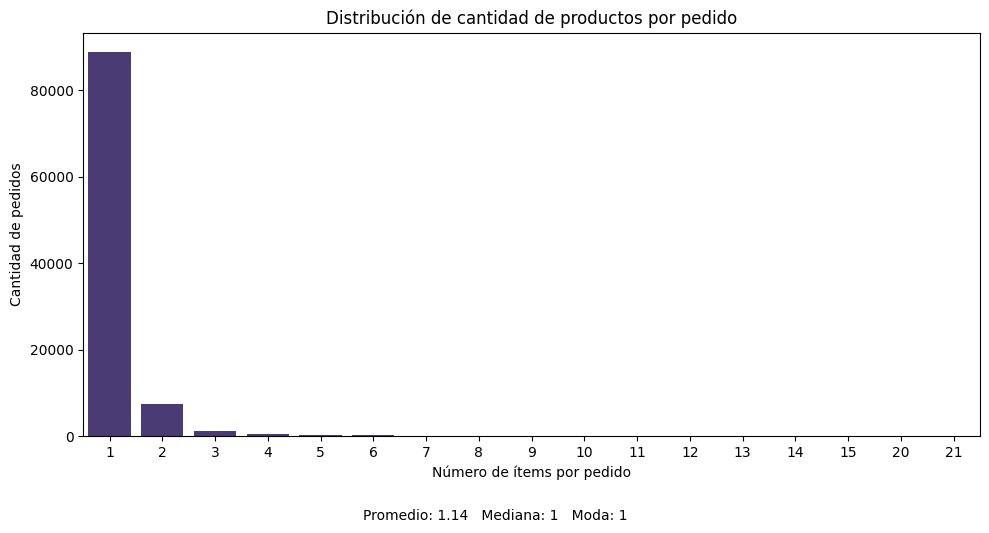

In [13]:
# Calculamos la cantidad de productos por pedido
items_por_pedido = df_items.groupby('order_id')['order_item_id'].count()

# ['qty_item_id'].count()   -Selecciona la columna 'qty_item_id' y cuenta la cantidad de filas que hay en cada grupo.

# Calculamos el promedio de ítems por pedido
promedio_items_por_pedido = items_por_pedido.mean()
mediana = items_por_pedido.median()
moda = items_por_pedido.mode()[0]

# También podemos ver la distribución para entender si son unitarios o múltiples
distribucion_items = items_por_pedido.value_counts().sort_index()

# Graficamos la distribución
plt.figure(figsize=(10, 5))
sns.barplot(x=distribucion_items.index, y=distribucion_items.values)
plt.xlabel('Número de ítems por pedido')
plt.ylabel('Cantidad de pedidos')
plt.title('Distribución de cantidad de productos por pedido')
plt.xticks(rotation=0)
plt.tight_layout()

# Agregar texto al pie del gráfico
texto_pie = f'Promedio: {promedio_items_por_pedido:.2f}   Mediana: {mediana:.0f}   Moda: {moda}'
plt.figtext(0.5, -0.05, texto_pie, wrap=True, horizontalalignment='center', fontsize=10)

plt.show()


En la gráfica se observa que los pedidos son mayoritariamente unitarios
Los valores informados al pie del gráfico representan lo siguiente
 Promedio     _ Tenemos una media de 1.14 articulos por pedido.  Esto significa

*   Promedio - Tenemos una media de 1.14 articulos por pedidos lo que indica que la mayoria de los pedidos tienen un solo producto.  Sin embargo, algunos pedidos con muchos items elevan ligeramente el promedio

*   Mediana - Nos confirma que al menos el 50% de los pedidos tienen exactamente un solo producto

*   Moda - La mayoria de los pedidos tienen exatamente 1 item

## 5.2 Precio promedio de los productos

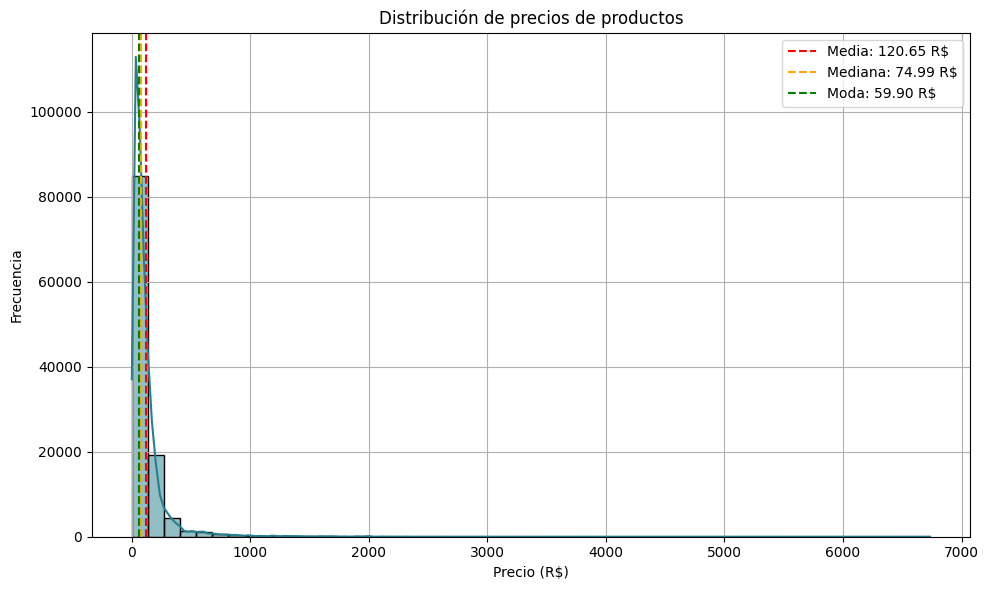

In [ ]:
# Asignación de color
viridis_color = sns.color_palette("viridis", as_cmap=False)[2]

# Calculo de estadísticas básicas
precio_mean = df_items['price'].mean()
precio_median = df_items['price'].median()
precio_min = df_items['price'].min()
precio_max = df_items['price'].max()
precio_moda = df_items['price'].mode()[0]

# Crear gráfico con todas las estadísticas
plt.figure(figsize=(10, 6))
sns.histplot(df_items['price'], bins=50, kde=True, color=viridis_color)

# Líneas verticales
plt.axvline(precio_mean, color='red', linestyle='--', label=f'Media: {precio_mean:.2f} R$')
plt.axvline(precio_median, color='orange', linestyle='--', label=f'Mediana: {precio_median:.2f} R$')
plt.axvline(precio_moda, color='green', linestyle='--', label=f'Moda: {precio_moda:.2f} R$')

# Etiquetas y detalles
plt.title('Distribución de precios de productos')
plt.xlabel('Precio (R$)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


En la gráfica se observa que la mayoria de los productos tienen precios bajos. La distribución sesgada hacia la derecha nos indica que existen productos con precios más altos pero poco frecuentes.

La **media** es de 120.65 (recoge outliers) y es mayor que la **mediana** 74.99.  Esto nos confirma que hay productos caros que elevan el promedio aunque la mayoría de productos tienen precios bajos.  

La **moda** 59.90 es el precio más frecuente entre todos los productos vendidos.

## 5.3 Costo envio promedio
Para este cálculo se considera la tabla **df_items_modificado** ya que tenemos que calcular el costo de envío por orden y producto.  En la tabla original el costo de envío se repetía en cada indice.

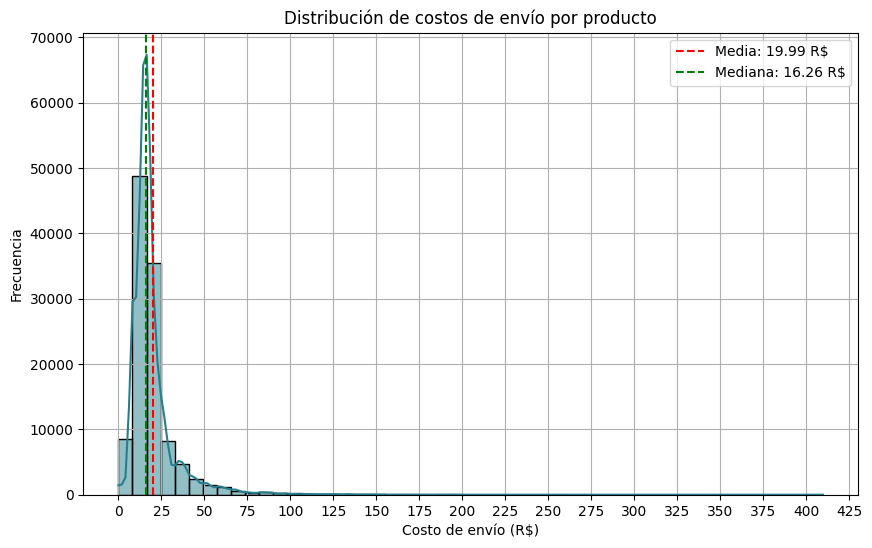

In [ ]:
# Calcular estadísticas básicas del costo de envío
freight_mean = df_items['freight_value'].mean()
freight_median = df_items['freight_value'].median()
freight_min = df_items['freight_value'].min()
freight_max = df_items['freight_value'].max()


# Obtener un color de la paleta viridis
viridis_color = sns.color_palette("viridis", as_cmap=False)[2]

# Crear gráfico de distribución del costo de envío
plt.figure(figsize=(10, 6))
sns.histplot(df_items['freight_value'], bins=50, kde=True, color=viridis_color)
plt.axvline(freight_mean, color='red', linestyle='--', label=f'Media: {freight_mean:.2f} R$')
plt.axvline(freight_median, color='green', linestyle='--', label=f'Mediana: {freight_median:.2f} R$')
plt.xticks(np.arange(0,450,25))
plt.title('Distribución de costos de envío por producto')
plt.xlabel('Costo de envío (R$)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(True)
plt.show()

El eje X nos muestra el costo de envio en R$.  En el eje Y se puede observar con que frecuencia aparece el costo de envío.
Lo que observamos es cuantos productos fueron enviados con un costo que cae dentro de cada intervalo.

La mayoría de los envío cuestan menos de 40, concentrandose fuertemente entre 0 y 25

La **media** 19.99 es mayor que la **mediana**  16.26 lo que confirma la presencia de outliers (costos de envío altos) que elevan el promedio

## 5.4 Precio de los productos

Visualizar dispersión y posibles valores atípicos del precio de los productos

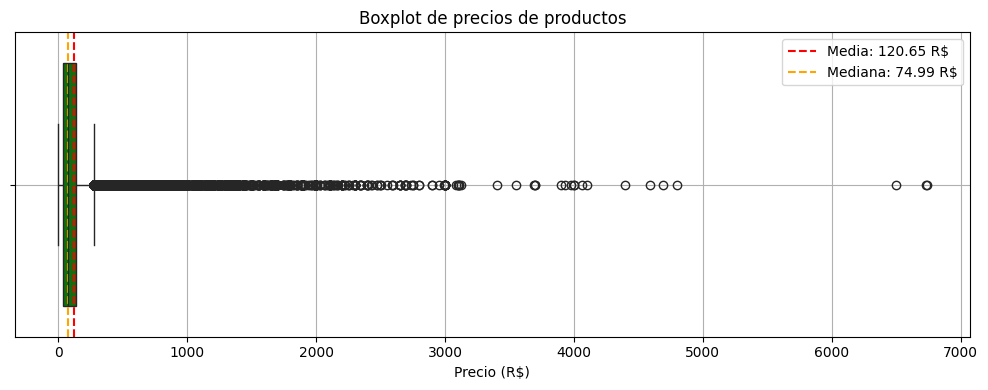

In [ ]:
# Calcular media y mediana
precio_mean = df_items['price'].mean()
precio_median = df_items['price'].median()

# Crear boxplot con líneas para media y mediana
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_items['price'], color='green')

# Líneas verticales para media y mediana
plt.axvline(precio_mean, color='red', linestyle='--', label=f'Media: {precio_mean:.2f} R$')
plt.axvline(precio_median, color='orange', linestyle='--', label=f'Mediana: {precio_median:.2f} R$')

# Etiquetas
plt.title('Boxplot de precios de productos')
plt.xlabel('Precio (R$)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


En la 'caja' representa el 50% central de los datos (rango intercuartílico, IQR)
Los bordes izquierdo y derecho de la 'caja' indican el el 1er cuartil (Q1) y el 3er cuartil (Q3).
La linea dentro de la caja representa la mediana.

Los 'bigotes' se extienen hasta los valores máximos y mínimos que no se consideran atípicos.  La longitud esta estimada a 1.5 veces el IQR desde los cuartiles.

Los puntos individuales representan outliers o valores atípicos.

Considerando lo anterior, se observan valores atípicos (otuliers) a la derecha del gráfico lo que significa que hay productos con precios considerablemente altos
La 'caja' esta comprimida hacia la izquieda (precios bajos).


La alta cantidad de valores atípicos (otuliers) hacia la derecha (precios altos), justifican la diferencia entre la media y la mediana.

### 5.4.1 Eliminación de otuliers

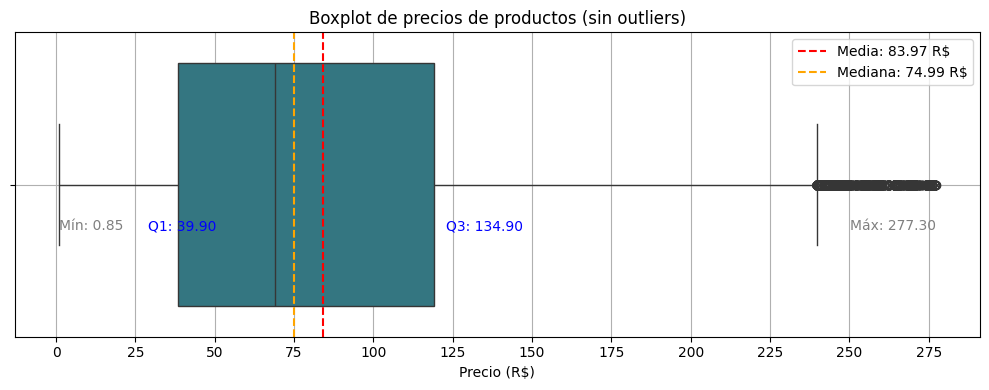

In [ ]:
# Calcular cuartiles y rango intercuartílico
q1 = df_items['price'].quantile(0.25)
q3 = df_items['price'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
q2 = df_items['price'].median()

# Filtrar el DataFrame para excluir outliers
df_filtrado = df_items[(df_items['price'] >= lower_bound) & (df_items['price'] <= upper_bound)].copy()

# Recalcular estadísticas para el DataFrame filtrado
mean_val = df_filtrado['price'].mean()
min_val = df_filtrado['price'].min()
max_val = df_filtrado['price'].max()

# Crear boxplot con el mismo estilo que el gráfico anterior y con anotaciones de Q1, Q3, Min, Max y Media
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_filtrado['price'], color=viridis_color)

# Líneas para media y mediana
plt.axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f} R$')
plt.axvline(q2, color='orange', linestyle='--', label=f'Mediana: {q2:.2f} R$')

# Anotar valores clave
plt.text(q1, 0.15, f'Q1: {q1:.2f}', ha='center', color='blue')
plt.text(q3, 0.15, f'Q3: {q3:.2f}', ha='center', color='blue')
plt.text(min_val, 0.15, f'Mín: {min_val:.2f}', ha='left', color='gray')
plt.text(max_val, 0.15, f'Máx: {max_val:.2f}', ha='right', color='gray')

# Estilo y etiquetas
max_tick = round(df_filtrado['price'].max() + 25, -1)
plt.xticks(np.arange(0, max_tick, 25))
plt.title('Boxplot de precios de productos (sin outliers)')
plt.xlabel('Precio (R$)')
plt.grid(True)
plt.legend()
plt.tight_layout()



Excluyendo los outliers se observa lo siguiente

| Quartil           |     Distribución   |     tipo de datos   
|-------------------|--------------------|---------------------
|**Q1(25%)** | (0-Q1) | El 25% de los productos cuesta menos de 39.90
|**Q2 (mediana)** | (Q1-Mediana) |El 50% de los productos cuesta menos de 74.99
|**Q3(75%)** | (Mediana-Q3) |El 75% de los productos cuesta menos de 134.90
| |(Q3-Max) | ** Mayor a 134.90


Se observa que la  'caja' es ancha por lo que hay una alta dispersíon entre los precios.

La mediana y la media no coincide, lo cual es típico en datos segados.

Los precios están concentrados entre 40 y 120, lo que sugiere que ese es el núcle del catálogo

La conclusión es que **la mayoria de los productos tienen precios bajos o moderados**


## 5.5 Productos con mayor precio promedio

Union de los datasets
* olist_order_items_dataset.csv
* olist_products_dataset.csv + product_category_name_translation.csv (ambos dataset se encuentran unidos)

Para obtener la descripcion del producto


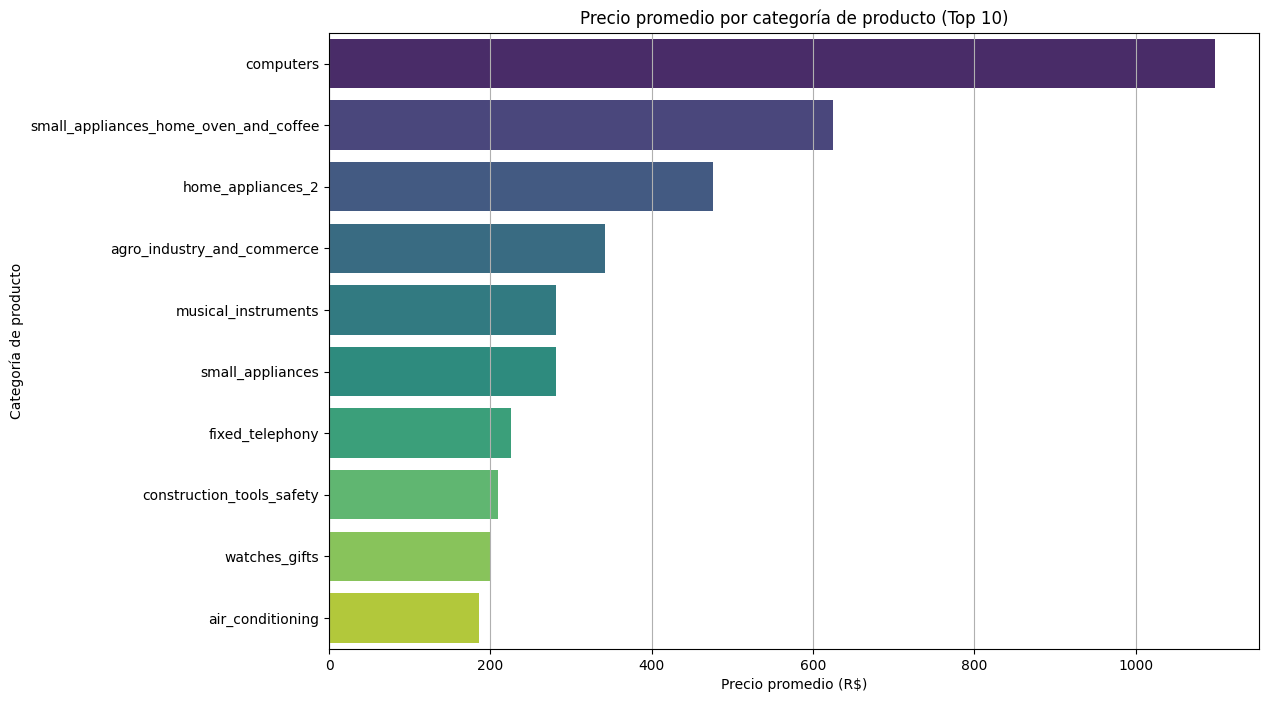

In [ ]:
# Calcular el precio promedio por categoría traducida (excluir nulos)
precio_por_categoria = df_items.groupby('product_category')['price'].mean().dropna().sort_values(ascending=False).head(10)

# Crear gráfico de barras
plt.figure(figsize=(12, 8))
sns.barplot(x=precio_por_categoria.values, y=precio_por_categoria.index, palette='viridis')
plt.title('Precio promedio por categoría de producto (Top 10)')
plt.xlabel('Precio promedio (R$)')
plt.ylabel('Categoría de producto')
plt.grid(True, axis='x')
plt.show()


El gráfico nos muestra las 10 categorías de productos con mayor precio promedio.

*   Las categorías como computers, small_appliances tienen precios promedio más altos
*   Las caterorías home_ampliances y agro_industry también destacan.  
  



## 5.6 Costo de envío

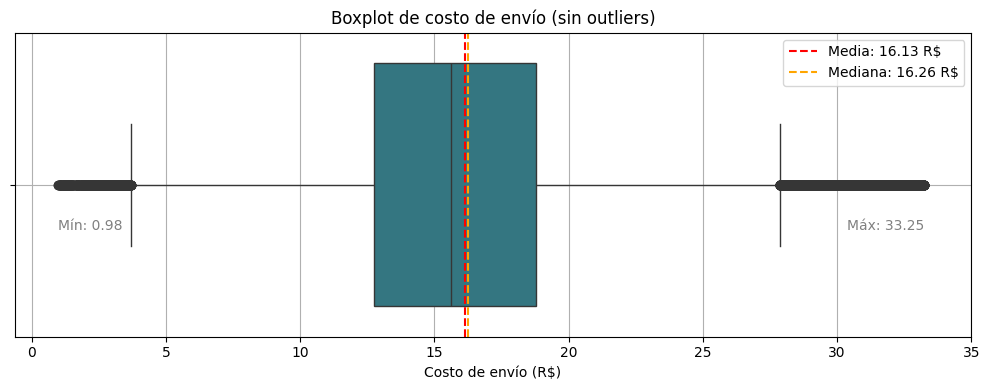

In [ ]:
# Calcular cuartiles y rango intercuartílico para el costo de envío (freight_value)
q1_f = df_items['freight_value'].quantile(0.25)
q3_f = df_items['freight_value'].quantile(0.75)
iqr_f = q3_f - q1_f
lower_bound_f = q1_f - 1.5 * iqr_f
upper_bound_f = q3_f + 1.5 * iqr_f
q2_f = df_items['freight_value'].median()

# Filtrar para excluir outliers
df_freight_filtrado = df_items[(df_items['freight_value'] >= lower_bound_f) & (df_items['freight_value'] <= upper_bound_f)].copy()

# Recalcular estadísticas
mean_f = df_freight_filtrado['freight_value'].mean()
min_f = df_freight_filtrado['freight_value'].min()
max_f = df_freight_filtrado['freight_value'].max()

# Crear boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_freight_filtrado['freight_value'], color=viridis_color)

# Líneas y anotaciones
plt.axvline(mean_f, color='red', linestyle='--', label=f'Media: {mean_f:.2f} R$')
plt.axvline(q2_f, color='orange', linestyle='--', label=f'Mediana: {q2_f:.2f} R$')
plt.text(min_f, 0.15, f'Mín: {min_f:.2f}', ha='left', color='gray')
plt.text(max_f, 0.15, f'Máx: {max_f:.2f}', ha='right', color='gray')

# Estética
max_tick_f = round(df_freight_filtrado['freight_value'].max() + 5, -1)
plt.xticks(np.arange(0, max_tick_f, 5))
plt.title('Boxplot de costo de envío (sin outliers)')
plt.xlabel('Costo de envío (R$)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


La 'caja' representa el rango intercuaritílico (IQR), es decir, el 50% central de los datos

| Quartil           |     Distribución   |     tipo de datos   
|-------------------|--------------------|---------------------
|**Q1(25%)** | (0-Q1) | El costo de envío del 25% de los productos cuesta menos de 13.08 BRL
|**Q3(75%)** | (Mediana-Q3) | El costo de envío del 75% de los productos cuesta menos de 21.15 BRL

Esto nos indica que el 50% central de los pedidos tiene un costo de envío entre 13.08 BRL y 21.15 BRL


## Paso 5.9 Categorías más vendidas e ingresos

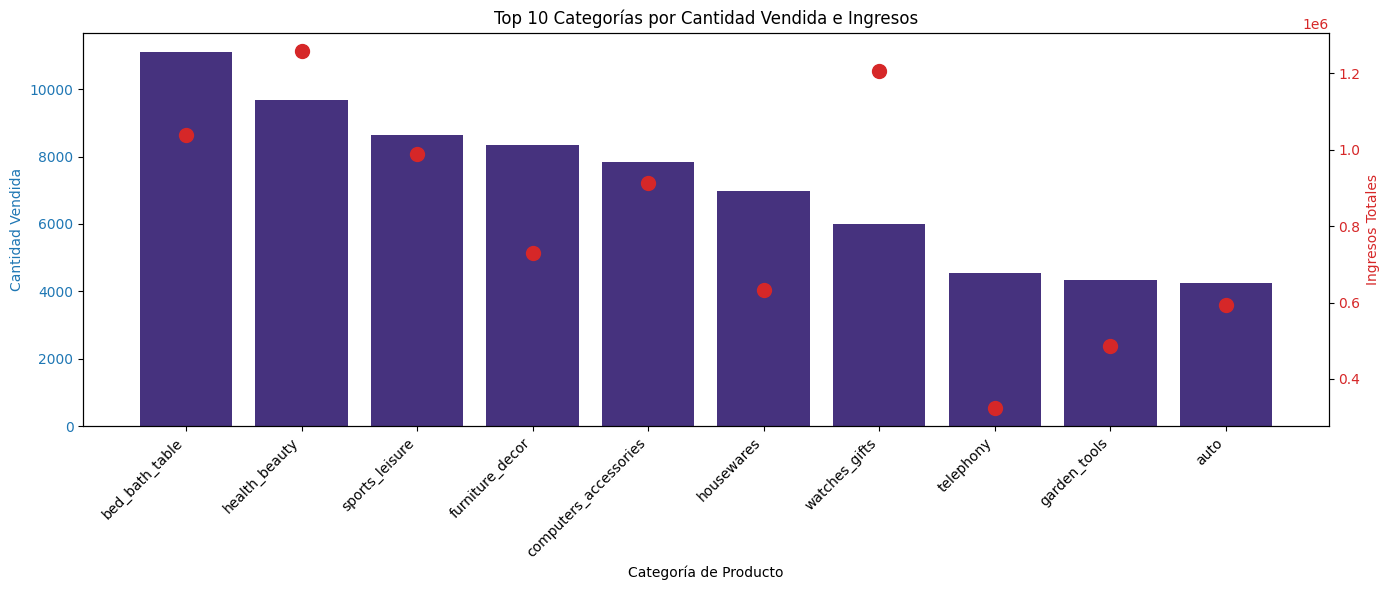

In [ ]:
# Calcular ingresos por producto
ingresos_por_producto = (
    df_items.groupby('product_id')['price']
    .sum()
    .reset_index()
    .rename(columns={'price': 'ingresos'})
)

# Calcular cantidad de ventas por producto
ventas_por_producto = (
    df_items.groupby('product_id')
    .size()
    .reset_index(name='cantidad_vendida')
)

# Unir ventas e ingresos
ventas_ingresos = pd.merge(ventas_por_producto, ingresos_por_producto, on='product_id', how='left')

# Agregar categoría de producto
producto_categoria = df_items[['product_id', 'product_category']].drop_duplicates()
ventas_ingresos = pd.merge(ventas_ingresos, producto_categoria, on='product_id', how='left')

# Agrupar por categoría
resumen_categoria = (
    ventas_ingresos.groupby('product_category')[['cantidad_vendida', 'ingresos']]
    .sum()
    .reset_index()
)

# Top 10 categorías más vendidas
top_categorias = resumen_categoria.sort_values(by='cantidad_vendida', ascending=False).head(10)

# Gráfico
fig, ax1 = plt.subplots(figsize=(14, 6))

# Barras para cantidad vendida (color por defecto)
ax1.bar(top_categorias['product_category'],
        top_categorias['cantidad_vendida'])

ax1.set_xlabel('Categoría de Producto')
ax1.set_ylabel('Cantidad Vendida', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticklabels(top_categorias['product_category'], rotation=45, ha='right')

# Puntos individuales para ingresos (sin línea)
ax2 = ax1.twinx()
ax2.scatter(top_categorias['product_category'],
            top_categorias['ingresos'],
            color='tab:red', marker='o', s=100)

ax2.set_ylabel('Ingresos Totales', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Top 10 Categorías por Cantidad Vendida e Ingresos')
fig.tight_layout()
plt.show()


## Paso 5.10 Ingresos por Categoria

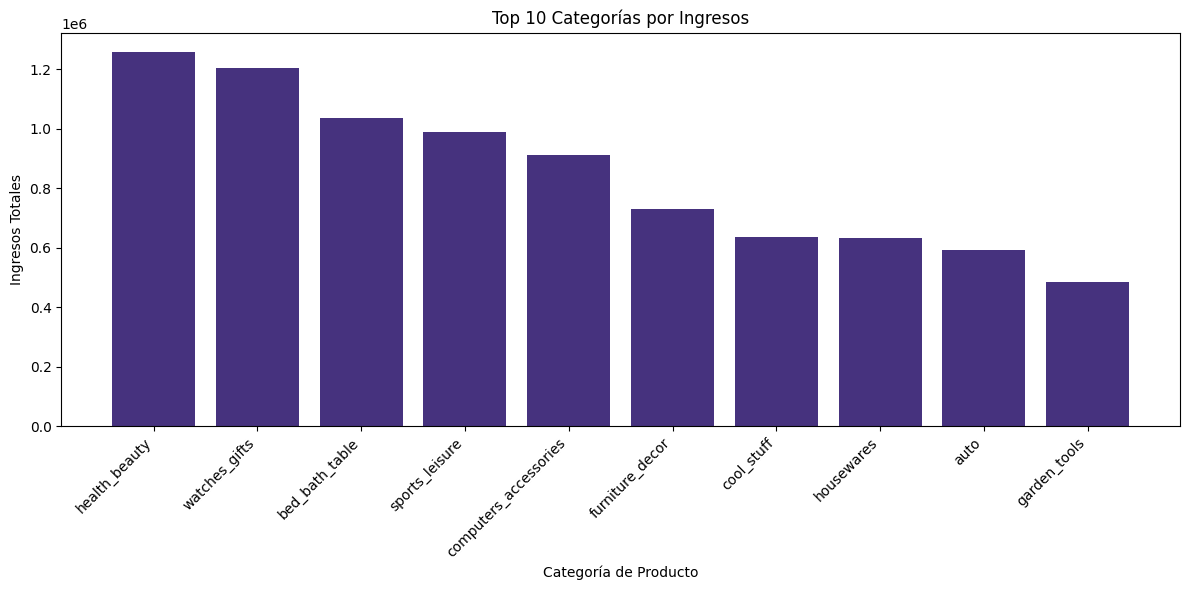

In [ ]:
# Calcular ingresos por producto
ingresos_por_producto = (
    df_items.groupby('product_id')['price']
    .sum()
    .reset_index()
    .rename(columns={'price': 'ingresos'})
)

# Extraer categorías directamente de df_items
producto_categoria = df_items[['product_id', 'product_category']].drop_duplicates()

# Unir ingresos con categoría
ingresos_con_categoria = pd.merge(
    ingresos_por_producto,
    producto_categoria,
    on='product_id',
    how='left'
)

# Agrupar por categoría
ingresos_por_categoria = (
    ingresos_con_categoria
    .groupby('product_category')['ingresos']
    .sum()
    .reset_index()
)

# Top 10 categorías
ingresos_por_categoria = ingresos_por_categoria.sort_values(by='ingresos', ascending=False).head(10)

# Gráfico
plt.figure(figsize=(12, 6))
plt.bar(ingresos_por_categoria['product_category'], ingresos_por_categoria['ingresos'])
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Categorías por Ingresos')
plt.xlabel('Categoría de Producto')
plt.ylabel('Ingresos Totales')
plt.tight_layout()
plt.show()



## Paso 5.11 Relación costo de envio / Precio

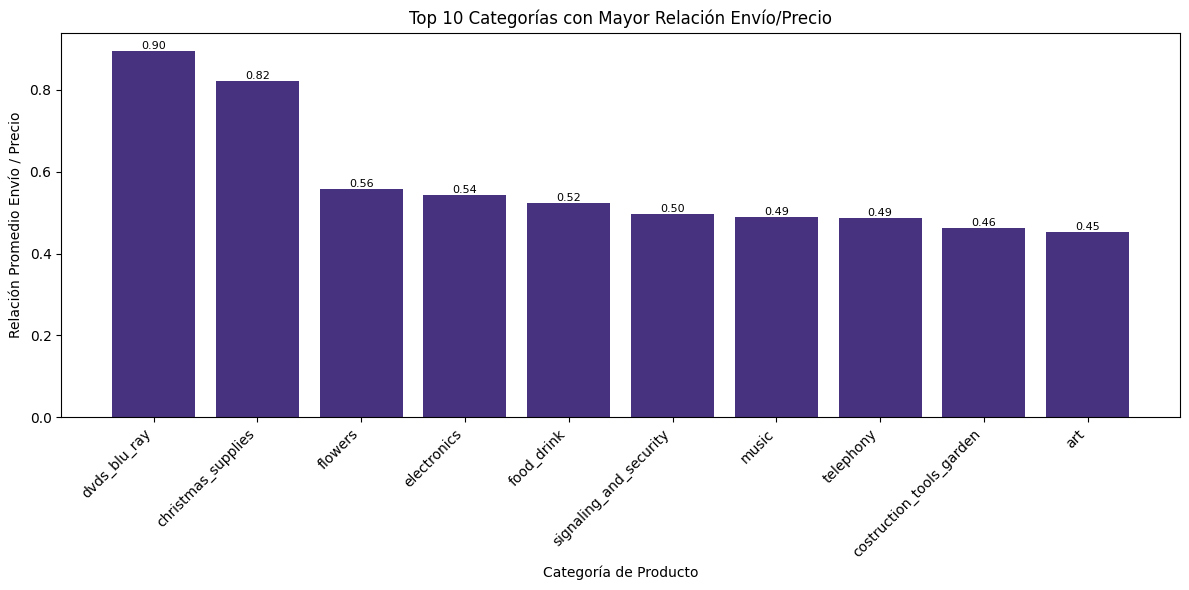

In [ ]:
# Calcular precio y valor de envío promedio por producto
precio_envio_relacion = (
    df_items.groupby('product_id')[['price', 'freight_value']]
    .mean()
    .reset_index()
)

# Calcular relación entre envío y precio
precio_envio_relacion['relacion_envio_precio'] = (
    precio_envio_relacion['freight_value'] / precio_envio_relacion['price']
)

# Extraer categorías directamente desde df_items
producto_categoria = df_items[['product_id', 'product_category']].drop_duplicates()

# Unir con categorías
precio_envio_relacion = pd.merge(
    precio_envio_relacion,
    producto_categoria,
    on='product_id',
    how='left'
)

# Calcular la relación promedio entre envío y precio por categoría
relacion_envio_categoria = (
    precio_envio_relacion
    .groupby('product_category')['relacion_envio_precio']
    .mean()
    .reset_index()
    .sort_values(by='relacion_envio_precio', ascending=False)
    .head(10)
)

# Gráfico
plt.figure(figsize=(12, 6))
bars = plt.bar(
    relacion_envio_categoria['product_category'],
    relacion_envio_categoria['relacion_envio_precio']
)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Categorías con Mayor Relación Envío/Precio')
plt.xlabel('Categoría de Producto')
plt.ylabel('Relación Promedio Envío / Precio')

# Añadir etiquetas
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


El gráfico muestra las 10 categorías de productos con la mayor relacion promedio entre el valor de envío (freiht_value) y el precio (price) de los productos


El eje Y nos arroja la relación promedio entre envío y precio.  valor del envío promedio / precio promedio

* La relación >1 el envío cuesta más que el producto en promedio.  Esto ocurre con productos muy baratos que aún requieren envío físico.

* La relación cercana a 1 el envio cuesta casi lo  mismo que el producto

* Relación <1 el envío es más barato que el producto (esto es habitual en productos de mayor valor)


Con este gráfico podemos identificar
   - productos donde el costo de envio podría disuadir al cliente
   - podríamos valorar cambiar proveedores lógisticos
   - crear políticas de envio diferentes (por ejemplo, incluir el envio en el precio)
   - crear packs de envio

## Paso 5.12 Vendedores con más ventas


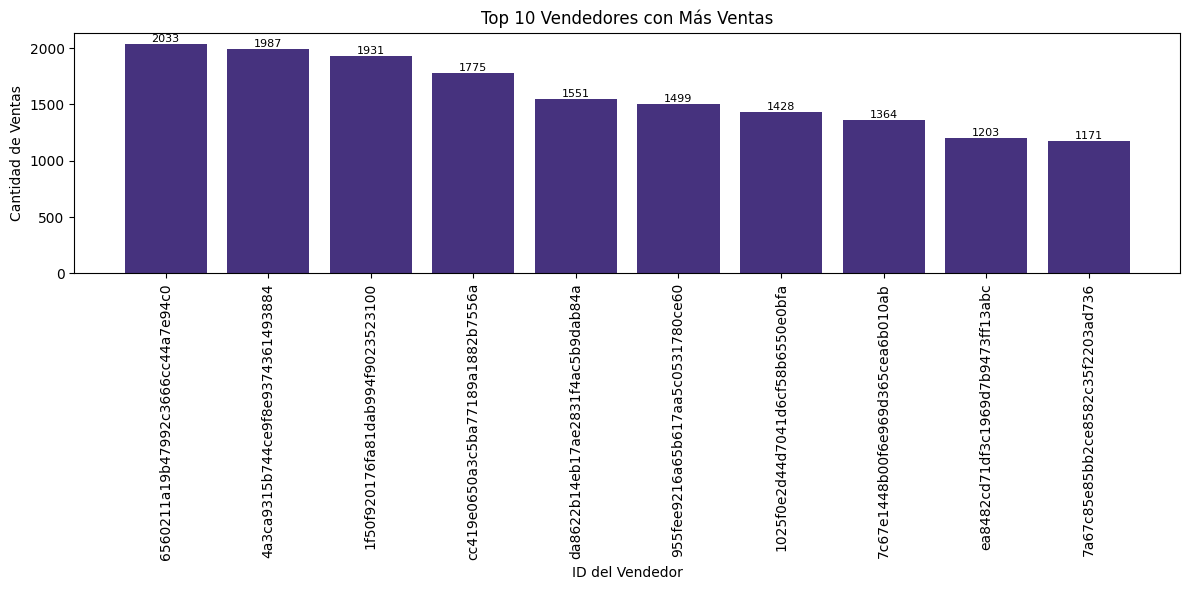

In [ ]:
# Calcular la cantidad de ventas por vendedor
ventas_por_vendedor = (
    df_items.groupby('seller_id')
    .size()
    .reset_index(name='cantidad_ventas')
    .sort_values(by='cantidad_ventas', ascending=False)
)

# Seleccionar los 10 vendedores con más ventas
top_10_vendedores = ventas_por_vendedor.head(10)

# Crear gráfico de barras (sin paleta de colores)
plt.figure(figsize=(12, 6))
bars = plt.bar(top_10_vendedores['seller_id'],
               top_10_vendedores['cantidad_ventas'])  # color por defecto

plt.xticks(rotation=90)
plt.title('Top 10 Vendedores con Más Ventas')
plt.xlabel('ID del Vendedor')
plt.ylabel('Cantidad de Ventas')

# Mostrar valores encima de las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{int(yval)}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()



## Paso 5.13 Ingresos por vendedor

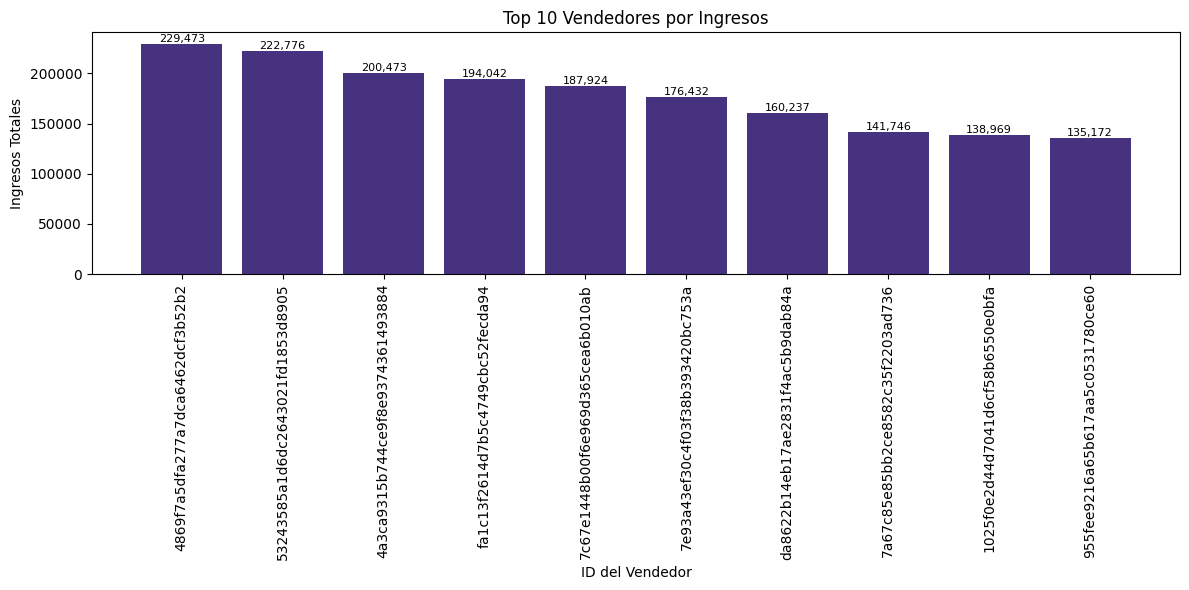

In [ ]:
# Calcular ingresos totales por vendedor
ingresos_por_vendedor = (
    df_items.groupby('seller_id')['price']
    .sum()
    .reset_index()
    .rename(columns={'price': 'ingresos'})
    .sort_values(by='ingresos', ascending=False)
)

# Seleccionar los 10 con más ingresos
top_10_ingresos_vendedor = ingresos_por_vendedor.head(10)

# Gráfico
plt.figure(figsize=(12, 6))
bars = plt.bar(top_10_ingresos_vendedor['seller_id'],
               top_10_ingresos_vendedor['ingresos'])  # color por defecto

plt.xticks(rotation=90)
plt.title('Top 10 Vendedores por Ingresos')
plt.xlabel('ID del Vendedor')
plt.ylabel('Ingresos Totales')

# Añadir valores encima de las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()



## Paso 5.14 Vendedores por ventas e ingresos


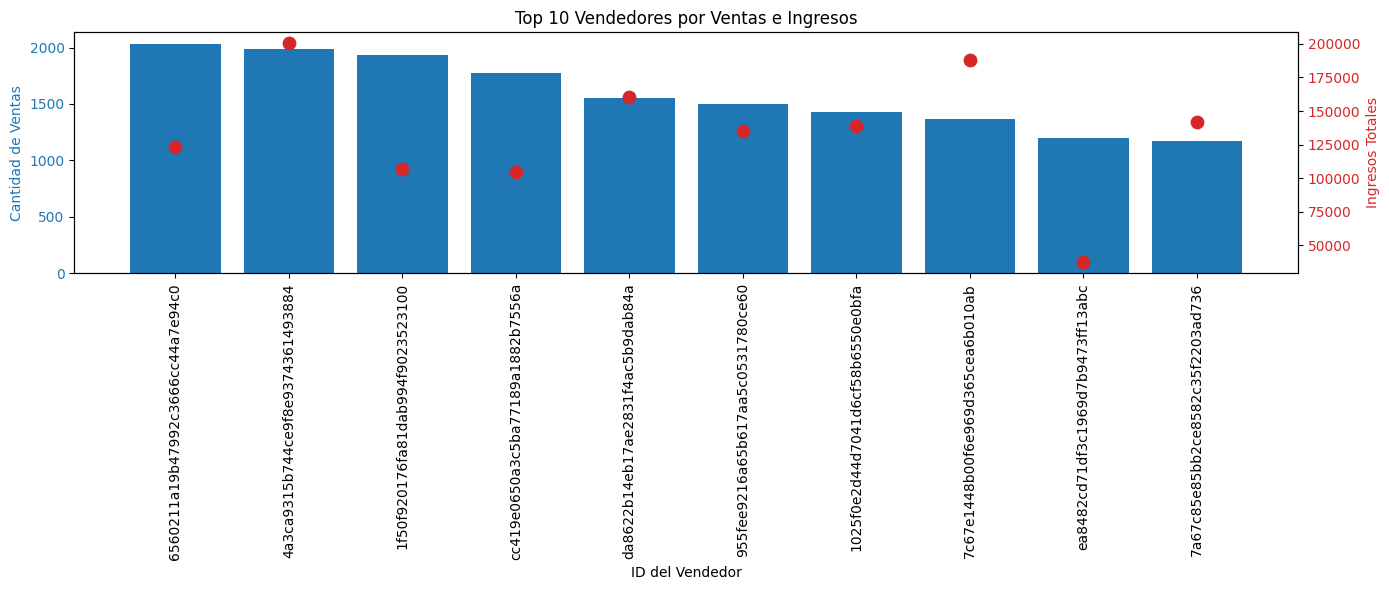

In [ ]:
# Calcular cantidad de ventas por vendedor
ventas_por_vendedor = (
    df_items.groupby('seller_id')
    .size()
    .reset_index(name='cantidad_ventas')
)

# Calcular ingresos por vendedor
ingresos_por_vendedor = (
    df_items.groupby('seller_id')['price']
    .sum()
    .reset_index()
    .rename(columns={'price': 'ingresos'})
)

# Combinar ambas métricas
resumen_vendedores = pd.merge(ventas_por_vendedor, ingresos_por_vendedor, on='seller_id')
resumen_vendedores = resumen_vendedores.sort_values(by='cantidad_ventas', ascending=False).head(10)

# Crear gráfico combinado
fig, ax1 = plt.subplots(figsize=(14, 6))

# Barras: cantidad de ventas (color por defecto)
ax1.set_xlabel('ID del Vendedor')
ax1.set_ylabel('Cantidad de Ventas', color='tab:blue')
bars1 = ax1.bar(resumen_vendedores['seller_id'],
                resumen_vendedores['cantidad_ventas'],
                color='tab:blue',
                label='Cantidad de Ventas')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticks(range(len(resumen_vendedores)))
ax1.set_xticklabels(resumen_vendedores['seller_id'], rotation=90)

# Puntos individuales: ingresos (sin línea)
ax2 = ax1.twinx()
ax2.set_ylabel('Ingresos Totales', color='tab:red')
ax2.scatter(range(len(resumen_vendedores)),
            resumen_vendedores['ingresos'],
            color='tab:red',
            label='Ingresos',
            marker='o',
            s=80)
ax2.tick_params(axis='y', labelcolor='tab:red')

# Título
plt.title('Top 10 Vendedores por Ventas e Ingresos')
fig.tight_layout()
plt.show()



## Paso 5.15 Categorias principales de los 10 vendedores más activos

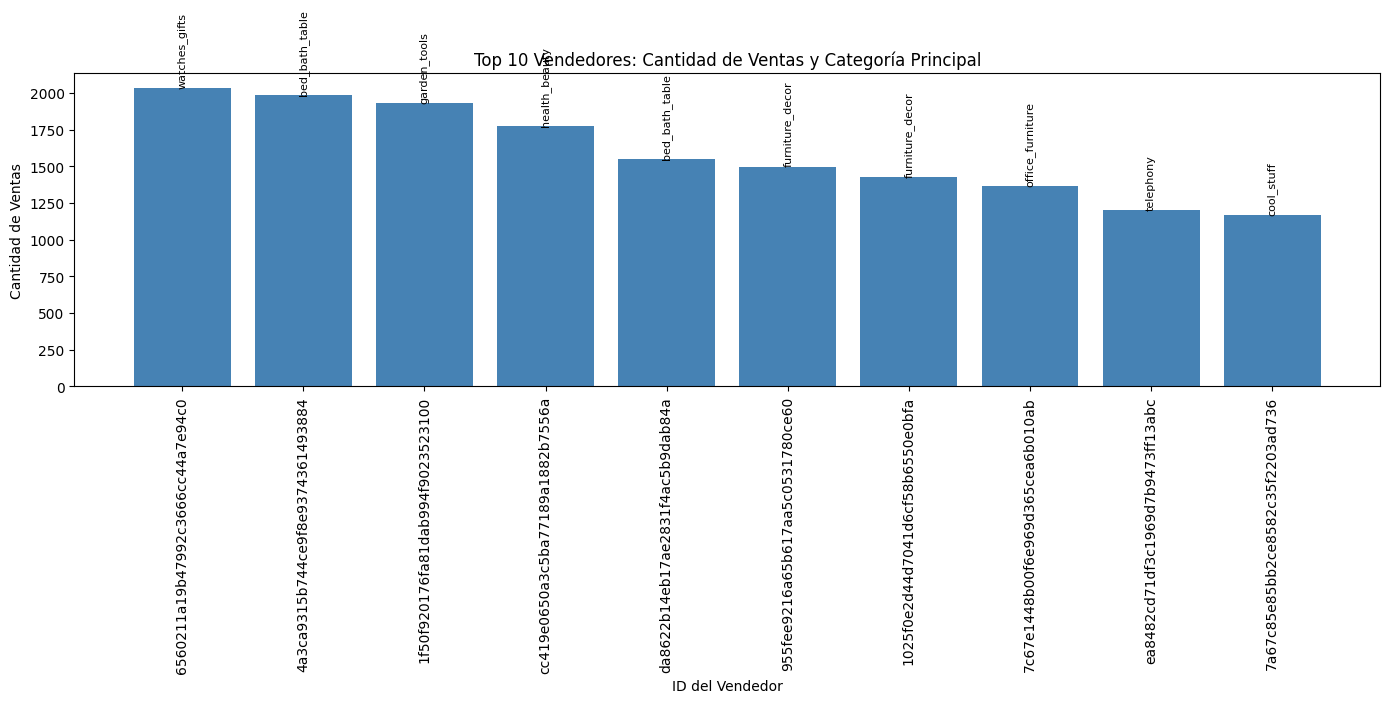

In [ ]:
plt.figure(figsize=(14, 7))
bars = plt.bar(
    resumen_vendedores_categoria['seller_id'],
    resumen_vendedores_categoria['cantidad_ventas'],
    color='steelblue'
)
plt.xticks(rotation=90)
plt.title('Top 10 Vendedores: Cantidad de Ventas y Categoría Principal')
plt.xlabel('ID del Vendedor')
plt.ylabel('Cantidad de Ventas')

# Añadir categoría como etiqueta encima de cada barra
for bar, categoria in zip(bars, resumen_vendedores_categoria['product_category']):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, categoria, ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

